# ICU Patient Mortality Risk Prediction
Comparing Logistic Regression, Random Forest, and Artificial Neural Network classifiers on the [PhysioNet 2012 Challenge dataset](https://physionet.org/content/challenge-2012/1.0.0/).

In [32]:
# Imports
import glob
import os
import pandas as pd
import numpy as np
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve, log_loss
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LSTM
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Recall, Precision, BinaryAccuracy
tf.random.set_seed(42)

In [33]:
# Constants
GENERAL_DESCRIPTORS = {"Time", "RecordID", "Age", "Gender", "Height", "ICUType", "Weight"}
BIOMETRICS = GENERAL_DESCRIPTORS - {"Time", "ICUType"}

In [34]:
def clean_patient_data(patient_file: str) -> pd.DataFrame:
    """
    Cleans a single patient's data.

    Args:
        patient_file (str): The path to the patient's data file.

    Returns:
        pd.DataFrame: The cleaned patient time series with columns:
        RecordID, Time, and one column per vital sign.
    """
    df = pd.read_csv(patient_file)

    # Clean time into minutes since.
    def to_minutes(time_str):
        h, m = map(int, time_str.split(':'))
        return h * 60 + m

    df["Time"] = df["Time"].apply(to_minutes)

    # Extract RecordID and remove it. We'll convert it into its own column.
    recordid = df.loc[df["Parameter"] == "RecordID", "Value"].values[0]
    df = df[df["Parameter"] != "RecordID"]

    # Pivot the data to have parameters as columns and timestamps as rows
    df = df.pivot_table(index="Time", columns="Parameter",
                        values="Value")

    # Sort by time for aggregation later.
    df.sort_index(inplace=True)

    # Per dataset description. -1 means it is missing value
    df = df.mask(df == -1)

    # Flatten to a tidy table for concatenation across all patients.
    df = df.reset_index()
    df["RecordID"] = int(recordid)
    return df

In [35]:
def _load_outcomes(data_set: str, data_root: str) -> pd.DataFrame:
    """
    Load survival outcomes for the selected dataset.
    -1 survival indicates the patient survived. All other numbers indicate days until death.

    Reads the outcomes file that corresponds to this loader's dataset
    identifier and returns only the columns needed for supervised learning.

    Columns:
        RecordID: Unique identifier for each patient record.
        Survival: The number of days between ICU admission and death or -1
                    if the patient survived. This excludes patients who
                    spent less than 48 hours in the ICU.

    Returns:
        pd.DataFrame: A DataFrame indexed by RecordID containing Survival.
                        Death is a binary column where 1 indicates risk and 0 indicates
                        no immediate risk.
    """
    outcomes_file_path = os.path.join(
        data_root, "outcomes", f"outcomes-{data_set}.txt")

    # We only care about RecordID and Survival
    df = pd.read_csv(outcomes_file_path, usecols=[
                     "RecordID", "Survival", "In-hospital_death"])
    df["Death"] = (df["In-hospital_death"] == 1).astype(int)
    df = df.drop(columns=["Survival", "In-hospital_death"])
    return df.set_index("RecordID")

In [36]:
def process_dataset(data_set: str, undersample: bool = False) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Loads and processes the patient data from the specified directory.
    Each set is expected to reside in a directory named
    "set-a", "set-b", or "set-c" under the data directory.

    Args:
        undersample: Whether to apply random undersampling on the majority
            class. This should generally be enabled only for training data.

    Returns:
        (pd.DataFrame, pd.DataFrame): A tuple containing the processed
        patient data and the corresponding outcomes.
        The shape of features is (record_id, vitals..., aggregated_vitals..., survival),
        where each time-varying vital is expanded into four features:
        *_mean, *_median, *_min, *_max, and *_std.
        Corresponding outcomes is a DataFrame indexed by RecordID containing Survival.
            -1 indicates patient survived.
    """
    if data_set not in {"a", "b", "c"}:
        raise ValueError('data_set must be one of "a", "b", or "c"')

    data_root = os.path.abspath(os.path.join("..", "..", "data"))
    dir_path = os.path.join(data_root, f"set-{data_set}")
    if not os.path.isdir(dir_path):
        raise FileNotFoundError(f"Dataset directory not found: {dir_path}")

    fp = glob.glob(os.path.join(dir_path, "*.txt"))
    patient_data = []

    for f in fp:
        patient_data.append(clean_patient_data(f))

    df_all = pd.concat(patient_data, ignore_index=True)

    # Grab all vital columns. Exclude general descriptors.
    vital_columns = [c for c in df_all.columns if c not in GENERAL_DESCRIPTORS]

    # Grab biometric columns, these should not be aggregated
    biometric_columns = [c for c in df_all.columns if c in BIOMETRICS]

    # Aggregate each vital over time into one row per patient.
    grouped = df_all.groupby("RecordID")[vital_columns]
    df_mean = grouped.mean().add_suffix("_mean")
    df_median = grouped.median().add_suffix("_median")
    df_min = grouped.min().add_suffix("_min")
    df_max = grouped.max().add_suffix("_max")
    df_std = grouped.std(ddof=0).add_suffix("_std")
    df_first = grouped.first().add_suffix("_first")
    df_last = grouped.last().add_suffix("_last")
    df_missing = grouped.count().eq(0).astype(int).add_suffix("_missing")

    df_delta = (
        df_last.rename(columns=lambda c: c.replace("_last", "")) -
        df_first.rename(columns=lambda c: c.replace("_first", ""))
    ).add_suffix("_delta")

    df_range = (
        df_max.rename(columns=lambda c: c.replace("_max", "")) -
        df_min.rename(columns=lambda c: c.replace("_min", ""))
    ).add_suffix("_range")

    df_features = pd.concat(
        [
            df_mean, df_median, df_min, df_max, df_std,
            df_first, df_last, df_delta, df_missing, df_range
        ],
        axis=1
    )

    # Fill remaining NaNs
    df_features = df_features.fillna(df_features.median(numeric_only=True))

    # Fill missing biometrics: median for continuous, mode for Gender.
    # Would love to drop it but too many records are missing it.
    continuous_biometrics = [
        c for c in biometric_columns if c not in {"RecordID", "Gender"}]
    bio_medians = df_all[continuous_biometrics].median()
    df_all[continuous_biometrics] = df_all[continuous_biometrics].fillna(
        bio_medians)
    gender_mode = df_all["Gender"].mode()[0]
    df_all["Gender"] = df_all["Gender"].fillna(gender_mode)

    # One-hot encode ICUType
    icu_dummies = pd.get_dummies(df_all[["RecordID", "ICUType"]], columns=[
                                 "ICUType"], dummy_na=True)
    icu_dummies = icu_dummies.drop_duplicates(
        subset="RecordID").set_index("RecordID").astype(float)
    df_features = df_features.join(icu_dummies)

    # Add the biometrics, unaggregated.
    df_features = df_features.join(df_all[biometric_columns].drop_duplicates(
        subset="RecordID").set_index("RecordID"), how="left")

    # Sort columns to guarantee consistent feature order across datasets.
    df_features = df_features[sorted(df_features.columns)]

    outcomes = _load_outcomes(data_set, data_root)

    if undersample:
        rus = RandomUnderSampler(sampling_strategy="majority", random_state=42)
        return rus.fit_resample(df_features, outcomes)

    return df_features, outcomes

In [37]:
def plot_metric_summary(y_true: np.ndarray, y_pred: np.ndarray, y_score: np.ndarray, title: str = 'Model'):
    """
    Prints classification report and plots roc_auc, precision, recall, and accuracy as bar chart.

    Args:
        y_true: True labels.
        y_pred: Predicted labels.
        y_score: Predicted scores or probabilities.
        title: Title for the plots and print statements.

    """
    print(f'{title} — test evaluation')
    print(classification_report(y_true, y_pred))

    roc_auc   = roc_auc_score(y_true, y_score)
    precision = precision_score(y_true, y_pred)
    recall    = recall_score(y_true, y_pred)
    accuracy  = (y_pred == y_true).mean()

    metric_names  = ['ROC-AUC', 'Precision', 'Recall', 'Accuracy']
    metric_values = [roc_auc, precision, recall, accuracy]

    plt.figure(figsize=(9, 5))
    bars = plt.bar(metric_names, metric_values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
    plt.ylim(0, 1)
    plt.ylabel('Score')
    plt.title(f'{title} — Test Metrics')
    for bar, value in zip(bars, metric_values):
        plt.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f'{value:.3f}', ha='center', va='bottom')
    plt.tight_layout()
    # plt.savefig(f"{title}_roc_auc_precision_recall_accuracy.png")
    plt.show()

def plot_evaluation_panels(y_true: np.ndarray, y_pred: np.ndarray, y_score: np.ndarray, model_name: str = 'Model') -> tuple[plt.Figure, np.ndarray]:
    """
    Plots evaluation panels including confusion matrix, ROC curve, and precision-recall curve.

    Args:
        y_true: True labels.
        y_pred: Predicted labels.
        y_score: Predicted scores or probabilities.
        model_name: Name of the model for titles.

    Returns:
        Tuple containing the figure and axes.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=axes[0], cmap='Blues')
    axes[0].set_title(f'{model_name} Confusion Matrix')
    RocCurveDisplay.from_predictions(y_true, y_score, ax=axes[1], name=model_name)
    axes[1].set_title(f'{model_name} ROC Curve')
    PrecisionRecallDisplay.from_predictions(y_true, y_score, ax=axes[2], name=model_name)
    axes[2].set_title(f'{model_name} Precision-Recall Curve')
    plt.tight_layout()
    plt.show()
    return fig, axes

def plot_threshold_tradeoff(y_true: np.ndarray, y_score: np.ndarray, chosen_threshold: float, title: str):
    """
    Plots the tradeoff between precision, recall, and accuracy for different thresholds.

    Args:
        y_true: True labels.
        y_score: Predicted scores or probabilities.
        chosen_threshold: The threshold to highlight on the plot.
        title: Title for the plot.
    """
    # precision_recall_curve returns len(thresholds) + 1 values for precision/recall.
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_score)
    # Align by dropping the last precision/recall point (which has no matching threshold).
    accuracies = [((y_score >= t).astype(int) == y_true).mean() for t in thresholds]

    plt.figure(figsize=(9, 5))
    plt.plot(thresholds, precisions[:-1], label='Precision', color='#55A868')
    plt.plot(thresholds, recalls[:-1], label='Recall', color='#C44E52')
    plt.plot(thresholds, accuracies, label='Accuracy', color='#8172B2')
    plt.axvline(x=chosen_threshold, color='gray', linestyle='--', label=f'Chosen threshold ({chosen_threshold})')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def export_predictions(record_ids: np.ndarray, y_pred: np.ndarray, y_score: np.ndarray, model_name: str) -> str:
    """
    Exports model predictions to a CSV file.
    This needs to be used with the score.c script to produce s1 and s2 scores.

    Args:
        record_ids: Array of patient RecordIDs.
        y_pred: Predicted binary labels (0 = survived, 1 = at risk).
        y_score: Predicted risk probabilities.
        model_name: Name of the model, used to name the output file.

    Returns:
        Path to the written CSV file.
    """
    filename = f"../models/{model_name}_results.csv"
    pd.DataFrame({
        "RecordID": record_ids,
        "Survival_Prediction": y_pred,
        "Risk_Probability": y_score,
    }).to_csv(filename, index=False, header=False)
    print(f"Saved predictions to {filename}")
    return filename

## Setting up date for ANN and Gradient Boosting
### Findings on data
- All sets of data are highly imbalanced where there are many more patients that passed as opposed to survived.
  - To combat this, **Random Under Sampling** is performed on the training data.
- Timeseries data tabularized into 2d. To retain some of the timeseries, aggregations were made.
  - *_delta -> Delta between first and last vital taken
  - *_first -> First vital value
  - *_last  -> Last vital value
  - *_max   -> Max vital taken
  - *_mean  -> Mean of vitals taken
  - *_median -> Median of vitals taken
  - *_min   -> Min of median taken
  - *_missing -> Flag on whether this vital was not taken
  - *_range -> Range of vitals, (max - min)
  - *_std   -> Standard deviation between vitals

In [38]:
# Setup the data for ANN and GradientBoostingClassifier
df_x_train, df_y_train = process_dataset(data_set="a", undersample=True)
df_x_train_all, df_y_train_all = process_dataset(
    data_set="a", undersample=False)
df_x_test, df_y_test = process_dataset(data_set="b", undersample=False)
df_x_val, df_y_val = process_dataset(data_set="c", undersample=False)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(df_x_train)
x_train_all_scaled = scaler.transform(df_x_train_all)
x_test_scaled = scaler.transform(df_x_test)
x_val_scaled = scaler.transform(df_x_val)

y_train = df_y_train.values.ravel()
y_train_all = df_y_train_all.values.ravel()
y_test = df_y_test.values.ravel()
y_val = df_y_val.values.ravel()

ann_classes = np.unique(y_train_all)
ann_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=ann_classes,
    y=y_train_all,
)
ann_class_weight = {int(label): float(weight)
                    for label, weight in zip(ann_classes, ann_class_weights)}

# Dimensions of the data
print(f"Training set: {x_train_scaled.shape}, {y_train.shape}")
print(f"Full training set: {x_train_all_scaled.shape}, {y_train_all.shape}")
print(f"Validation set: {x_val_scaled.shape}, {y_val.shape}")
print(f"Test set: {x_test_scaled.shape}, {y_test.shape}")
print(f"ANN class weights: {ann_class_weight}")

Training set: (1108, 369), (1108,)
Full training set: (4000, 369), (4000,)
Validation set: (4000, 369), (4000,)
Test set: (4000, 369), (4000,)
ANN class weights: {0: 0.5803830528148578, 1: 3.6101083032490973}


## Artificial Neural Network
**Primary Contributor:** Jean Luis Urena

In here we train an Artificial Neural Network model.

- A threshold of > 0.4 was chosen after evaluating metrics and precision recall curve.
- The hyperparameters used here are the best parameters found after tuning using RandomizedSearchCV.

In [56]:
# Best parameters found:  {'model__neurons': 10, 'model__l2_reg': 0.001, 'model__dropout_rate': 0.7, 'epochs': 50, 'batch_size': 64}
early_stop = EarlyStopping(patience=30, restore_best_weights=True)
ann_model = Sequential([
    Input(shape=(x_train_all_scaled.shape[1],)),
    Dense(10, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.7),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

adam_optimizer = Adam(learning_rate=0.001)
ann_model.compile(
    optimizer=adam_optimizer,
    loss='binary_crossentropy',
    metrics=[
        AUC(name='auc'),
        Recall(name='recall'),
        Precision(name='precision'),
        BinaryAccuracy(name='accuracy')
    ]
)
history = ann_model.fit(
    x_train_all_scaled, y_train_all,
    validation_data=(x_val_scaled, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=ann_class_weight,
    verbose=0
)

ann_val_raw_prob = ann_model.predict(x_val_scaled, verbose=0).ravel()
ann_calibrator = IsotonicRegression(out_of_bounds='clip')
ann_calibrator.fit(ann_val_raw_prob, y_val)

,"y_min y_min: float, default=NoneLower bound on the lowest predicted value (the minimum value maystill be higher). If not set, defaults to -inf.",None
,"y_max y_max: float, default=NoneUpper bound on the highest predicted value (the maximum may still belower). If not set, defaults to +inf.",None
,"increasing increasing: bool or 'auto', default=TrueDetermines whether the predictions should be constrained to increaseor decrease with `X`. 'auto' will decide based on the Spearmancorrelation estimate's sign.",True
,"out_of_bounds out_of_bounds: {'nan', 'clip', 'raise'}, default='nan'Handles how `X` values outside of the training domain are handledduring prediction.- 'nan', predictions will be NaN.- 'clip', predictions will be set to the value corresponding to the nearest train interval endpoint.- 'raise', a `ValueError` is raised.",'clip'


ANN (threshold = 0.27, isotonic calibrated) — test evaluation
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      3432
           1       0.48      0.60      0.54       568

    accuracy                           0.85      4000
   macro avg       0.71      0.75      0.72      4000
weighted avg       0.87      0.85      0.86      4000



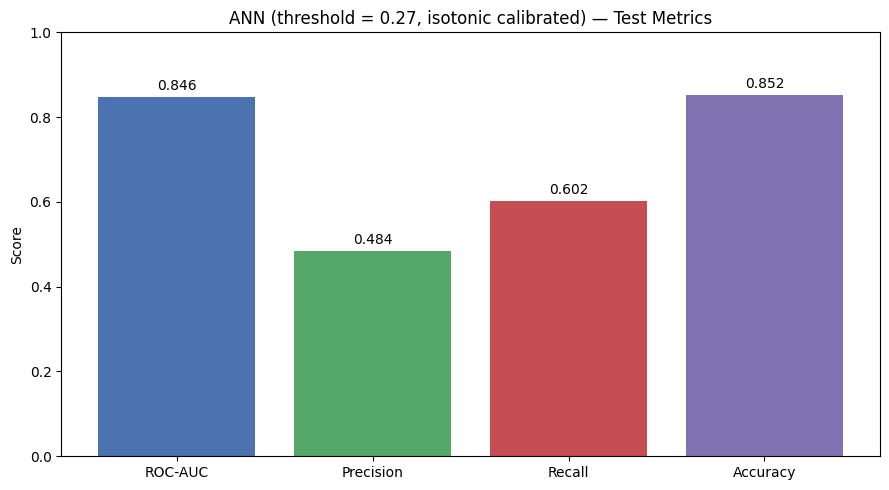

In [57]:
# Predict calibrated probabilities on test set, then apply a lower threshold to prioritize recall.
threshold = 0.27
ann_raw_prob = ann_model.predict(x_test_scaled, verbose=0).ravel()
y_score = ann_calibrator.predict(ann_raw_prob)
y_pred = (y_score > threshold).astype(int)

plot_metric_summary(y_test, y_pred, y_score, f'ANN (threshold = {threshold}, isotonic calibrated)')

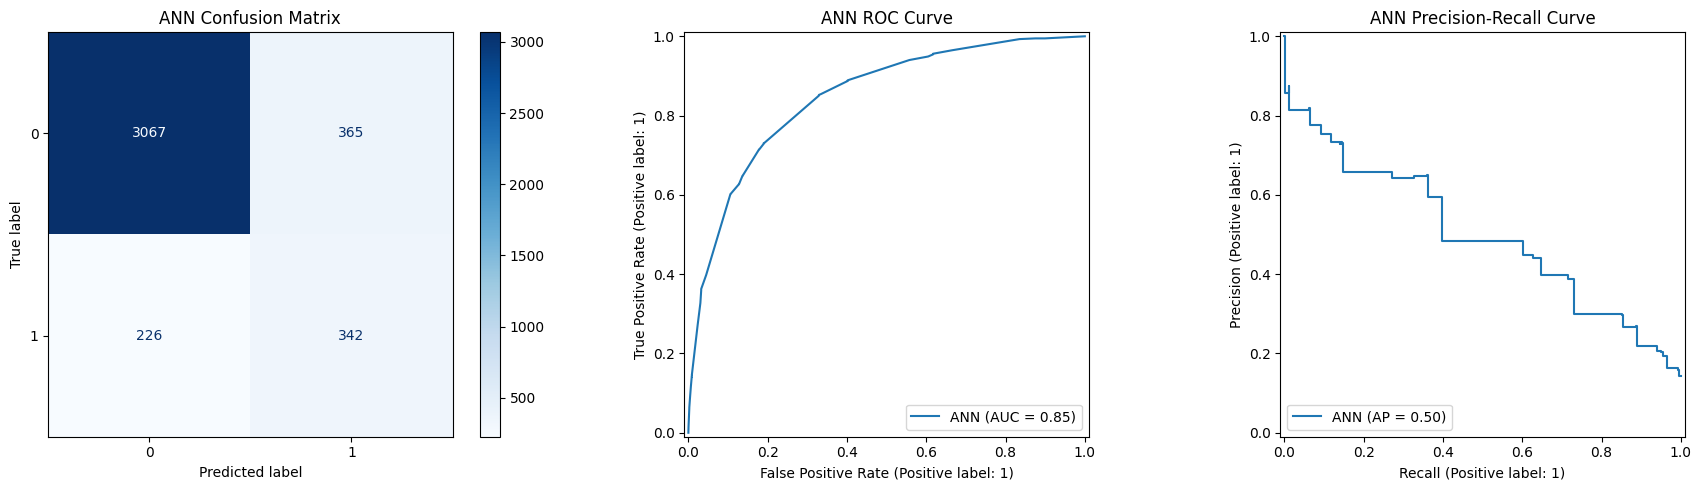

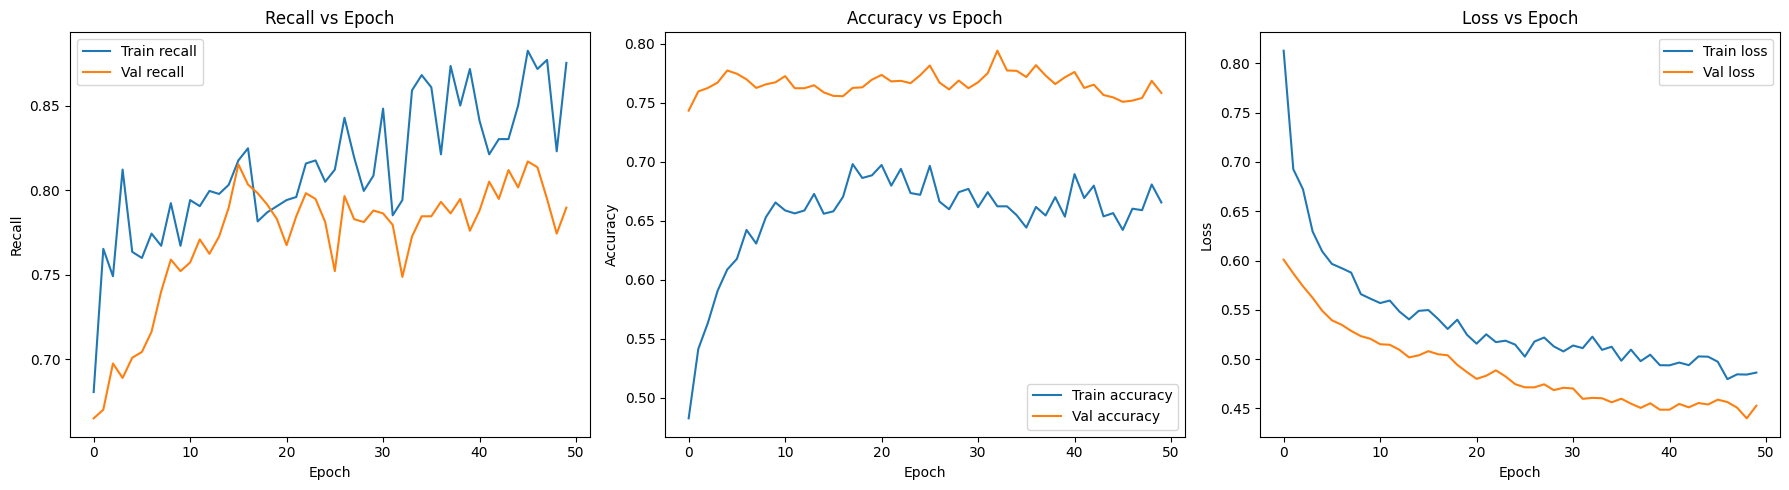

In [58]:
# Populate the 3-panel ANN evaluation figure.
ann_fig, ann_axes = plot_evaluation_panels(
    y_test, y_pred, y_score, model_name='ANN')

# Plot Recall, Accuracy, and Loss across epochs.
fig, metric_axes = plt.subplots(1, 3, figsize=(18, 5))

metric_axes[0].plot(history.history['recall'], label='Train recall')
metric_axes[0].plot(history.history['val_recall'], label='Val recall')
metric_axes[0].set_title('Recall vs Epoch')
metric_axes[0].set_xlabel('Epoch')
metric_axes[0].set_ylabel('Recall')
metric_axes[0].legend()

metric_axes[1].plot(history.history['accuracy'], label='Train accuracy')
metric_axes[1].plot(history.history['val_accuracy'], label='Val accuracy')
metric_axes[1].set_title('Accuracy vs Epoch')
metric_axes[1].set_xlabel('Epoch')
metric_axes[1].set_ylabel('Accuracy')
metric_axes[1].legend()

metric_axes[2].plot(history.history['loss'], label='Train loss')
metric_axes[2].plot(history.history['val_loss'], label='Val loss')
metric_axes[2].set_title('Loss vs Epoch')
metric_axes[2].set_xlabel('Epoch')
metric_axes[2].set_ylabel('Loss')
metric_axes[2].legend()

plt.tight_layout()
# plt.savefig("metrics_vs_epoch.png")
plt.show()

### Why Recall Prioritization?
We want to catch most at-risk patients. False positives are preferred over false negatives.

It is more important to monitor a patient that is **not at risk but deemed at risk** over missing on monitoring a patient that **is at risk but deemed NOT at risk**.

- At 0.4, recall is high. The trade-off is lower precision and accuracy.
- Moving the threshold right increases precision and accuracy but lowers recall.

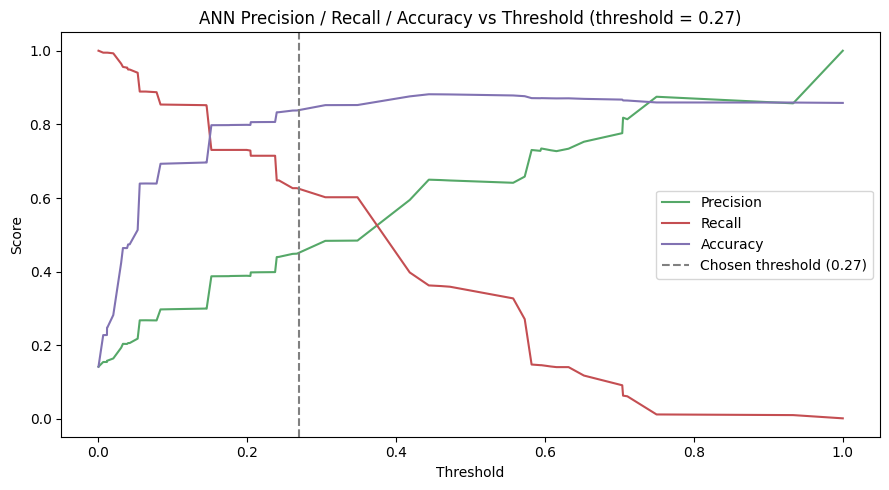

In [59]:
# Sweep all thresholds derived from the model's predicted probabilities.
plot_threshold_tradeoff(
    y_test,
    y_score,
    chosen_threshold=threshold,
    title=f'ANN Precision / Recall / Accuracy vs Threshold (threshold = {threshold})'
)

In [60]:
# Export ANN
export_predictions(df_y_test.index.values, y_pred, y_score, model_name='ANN')

Saved predictions to ../models/ANN_results.csv


'../models/ANN_results.csv'

In [61]:
# LSTM setup
# LSTM expects 3D input: (samples, timesteps, features_per_timestep)
# Here, each original feature is treated like one timestep with 1 feature.

x_train_lstm = x_train_scaled.reshape((x_train_scaled.shape[0], x_train_scaled.shape[1], 1))
x_val_lstm = x_val_scaled.reshape((x_val_scaled.shape[0], x_val_scaled.shape[1], 1))
x_test_lstm = x_test_scaled.reshape((x_test_scaled.shape[0], x_test_scaled.shape[1], 1))

lstm_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

lstm_model = Sequential([
    Input(shape=(x_train_lstm.shape[1], 1)),
    LSTM(32, return_sequences=False),
    Dropout(0.4),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        AUC(name="auc"),
        Recall(name="recall"),
        Precision(name="precision"),
        BinaryAccuracy(name="accuracy")
    ]
)

lstm_history = lstm_model.fit(
    x_train_lstm,
    y_train,
    validation_data=(x_val_lstm, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[lstm_early_stop],
    verbose=1
)

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.5144 - auc: 0.5288 - loss: 0.6918 - precision: 0.5109 - recall: 0.6751 - val_accuracy: 0.6090 - val_auc: 0.6016 - val_loss: 0.6877 - val_precision: 0.1844 - val_recall: 0.4889
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.5532 - auc: 0.5734 - loss: 0.6896 - precision: 0.5517 - recall: 0.5686 - val_accuracy: 0.5355 - val_auc: 0.6010 - val_loss: 0.6859 - val_precision: 0.1690 - val_recall: 0.5556
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.5424 - auc: 0.5919 - loss: 0.6842 - precision: 0.5376 - recall: 0.6065 - val_accuracy: 0.5268 - val_auc: 0.6099 - val_loss: 0.6865 - val_precision: 0.1743 - val_recall: 0.5983
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.5569 - auc: 0.5875 - loss: 0.6824 - precision: 0.5554 - recall: 0.5704 - val_accuracy: 0.6603 - val_auc: 0.6240 - val_loss: 0.6625 - val_precision: 0.2086 - val_recall: 0.4735
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━

LSTM (threshold = 0.4) — test evaluation
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      3432
           1       0.22      0.51      0.31       568

    accuracy                           0.68      4000
   macro avg       0.56      0.60      0.55      4000
weighted avg       0.80      0.68      0.72      4000



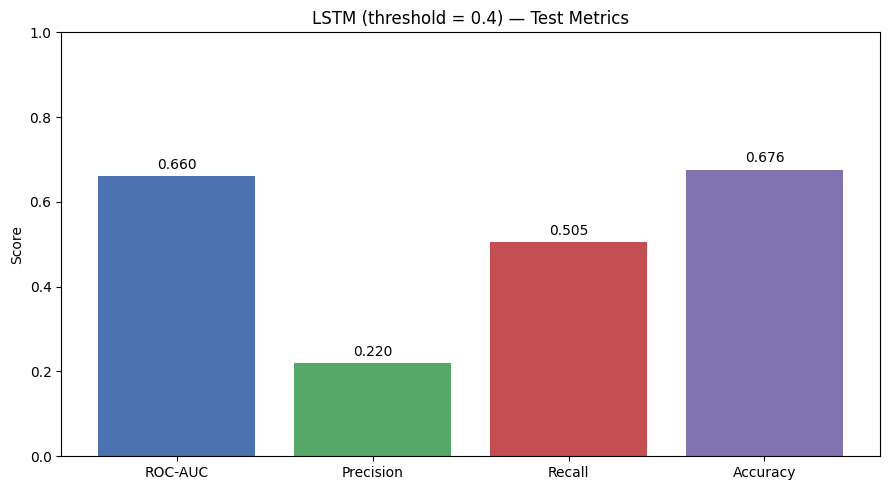

In [62]:
# Evaluate LSTM on test set
lstm_threshold = 0.4

lstm_score = lstm_model.predict(x_test_lstm, verbose=0).ravel()
lstm_pred = (lstm_score > lstm_threshold).astype(int)

plot_metric_summary(y_test, lstm_pred, lstm_score, title=f"LSTM (threshold = {lstm_threshold})")

In [63]:
export_predictions(df_y_test.index.values, lstm_pred, lstm_score, model_name='LSTM')

Saved predictions to ../models/LSTM_results.csv


'../models/LSTM_results.csv'

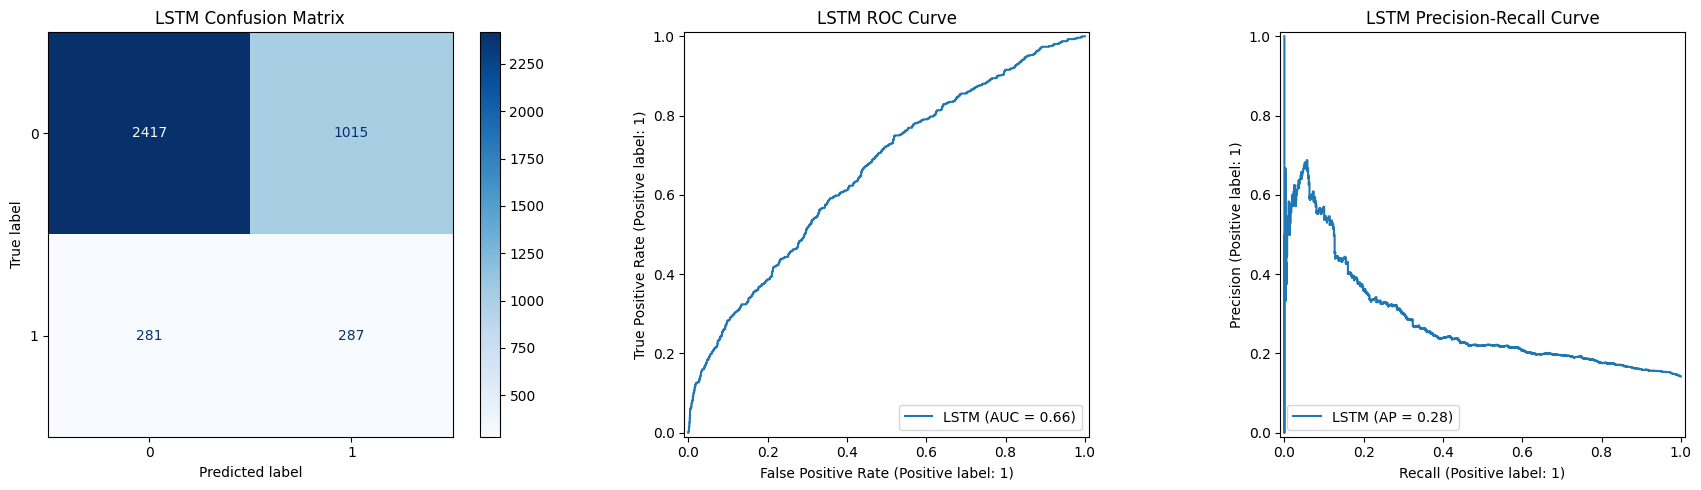

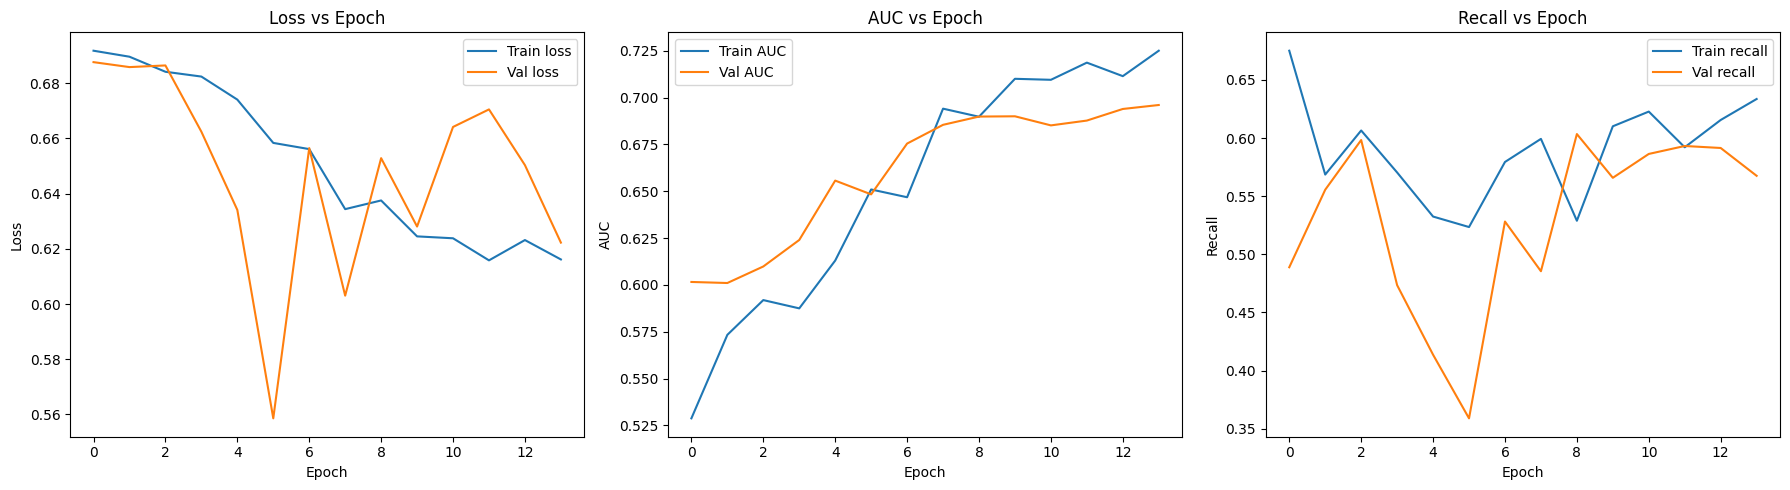

In [64]:
# Populate the 3-panel LSTM evaluation figure
lstm_fig, lstm_axes = plot_evaluation_panels(y_test, lstm_pred, lstm_score, model_name='LSTM')

# Plot Loss, AUC, and Recall across epochs
fig, lstm_metric_axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
lstm_metric_axes[0].plot(lstm_history.history['loss'], label='Train loss')
lstm_metric_axes[0].plot(lstm_history.history['val_loss'], label='Val loss')
lstm_metric_axes[0].set_title('Loss vs Epoch')
lstm_metric_axes[0].set_xlabel('Epoch')
lstm_metric_axes[0].set_ylabel('Loss')
lstm_metric_axes[0].legend()

# AUC
lstm_metric_axes[1].plot(lstm_history.history['auc'], label='Train AUC')
lstm_metric_axes[1].plot(lstm_history.history['val_auc'], label='Val AUC')
lstm_metric_axes[1].set_title('AUC vs Epoch')
lstm_metric_axes[1].set_xlabel('Epoch')
lstm_metric_axes[1].set_ylabel('AUC')
lstm_metric_axes[1].legend()

# Recall
lstm_metric_axes[2].plot(lstm_history.history['recall'], label='Train recall')
lstm_metric_axes[2].plot(lstm_history.history['val_recall'], label='Val recall')
lstm_metric_axes[2].set_title('Recall vs Epoch')
lstm_metric_axes[2].set_xlabel('Epoch')
lstm_metric_axes[2].set_ylabel('Recall')
lstm_metric_axes[2].legend()

plt.tight_layout()
plt.show()

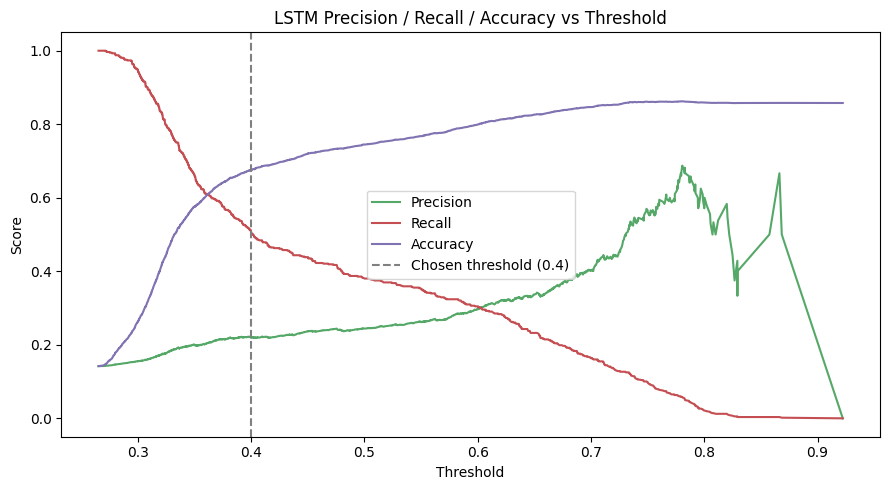

In [65]:
plot_threshold_tradeoff(
    y_test,
    lstm_score,
    chosen_threshold=lstm_threshold,
    title='LSTM Precision / Recall / Accuracy vs Threshold'
)

## Gradient Boosting Model
**Primary Contributor:** Sarvesh Kapil Pathak, Jean Luis Urena

- The hyperparameters used here are the best parameters found after tuning using GridSearchCV.
- Threshold was selected after tuning by iterating through a variety of thresholds.
- Training set **is not undersampled** as it impacts performance negatively. More samples better.



In [66]:
# best Params: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 200, 'subsample': 0.7}
grad_boost_params = {
    'learning_rate': 0.05,
    'max_depth': 4,
    'max_features': 'sqrt',
    'min_samples_leaf': 5,
    'n_estimators': 200,
    'random_state': 42,
    'subsample': 0.7
}

grad_boost_threshold = 0.5

gradient_boosting_model = GradientBoostingClassifier(**grad_boost_params)
# Hold out on validation set to track metrics.
gradient_boosting_model.fit(x_train_all_scaled, y_train_all)

train_prob_stages = list(gradient_boosting_model.staged_predict_proba(x_train_all_scaled))
val_prob_stages = list(gradient_boosting_model.staged_predict_proba(x_val_scaled))

train_loss = np.array([
    log_loss(y_train_all, y_proba[:, 1]) for y_proba in train_prob_stages
])
val_loss = np.array([
    log_loss(y_val, y_proba[:, 1]) for y_proba in val_prob_stages
])

train_recall = np.array([
    recall_score(y_train_all, (y_proba[:, 1] >= grad_boost_threshold).astype(int), zero_division=0)
    for y_proba in train_prob_stages
])
val_recall = np.array([
    recall_score(y_val, (y_proba[:, 1] >= grad_boost_threshold).astype(int), zero_division=0)
    for y_proba in val_prob_stages
])

train_accuracy = np.array([
    ((y_proba[:, 1] >= grad_boost_threshold).astype(int) == y_train_all).mean() for y_proba in train_prob_stages
])
val_accuracy = np.array([
    ((y_proba[:, 1] >= grad_boost_threshold).astype(int) == y_val).mean() for y_proba in val_prob_stages
])

# Refit on train+val for final test-set evaluation.
grad_boost_train_x = np.vstack([x_train_all_scaled, x_val_scaled])
grad_boost_train_y = np.hstack([y_train_all, y_val])
grad_boost_model = GradientBoostingClassifier(**grad_boost_params)
grad_boost_model.fit(grad_boost_train_x, grad_boost_train_y)

grad_boost_prob = grad_boost_model.predict_proba(x_test_scaled)[:, 1]

### Gradient Boosting Evaluation

Gradient Boosting (threshold = 0.5) — test evaluation
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      3432
           1       0.70      0.32      0.43       568

    accuracy                           0.88      4000
   macro avg       0.80      0.65      0.68      4000
weighted avg       0.87      0.88      0.86      4000



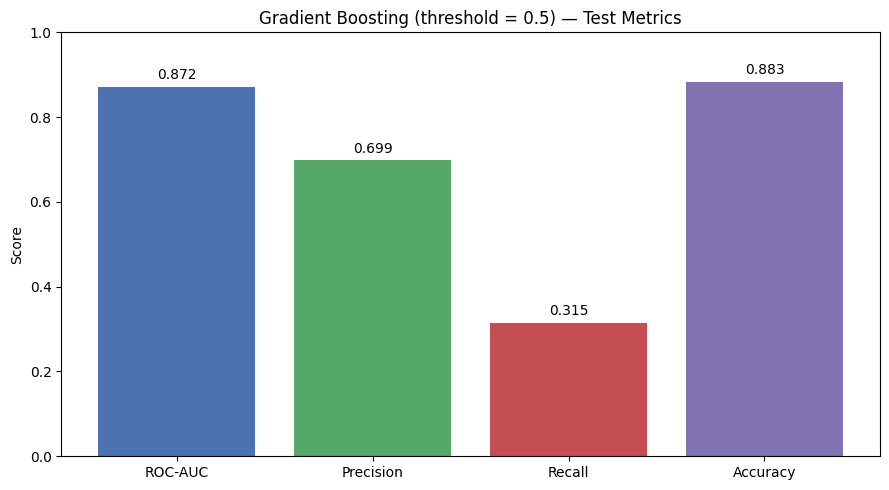

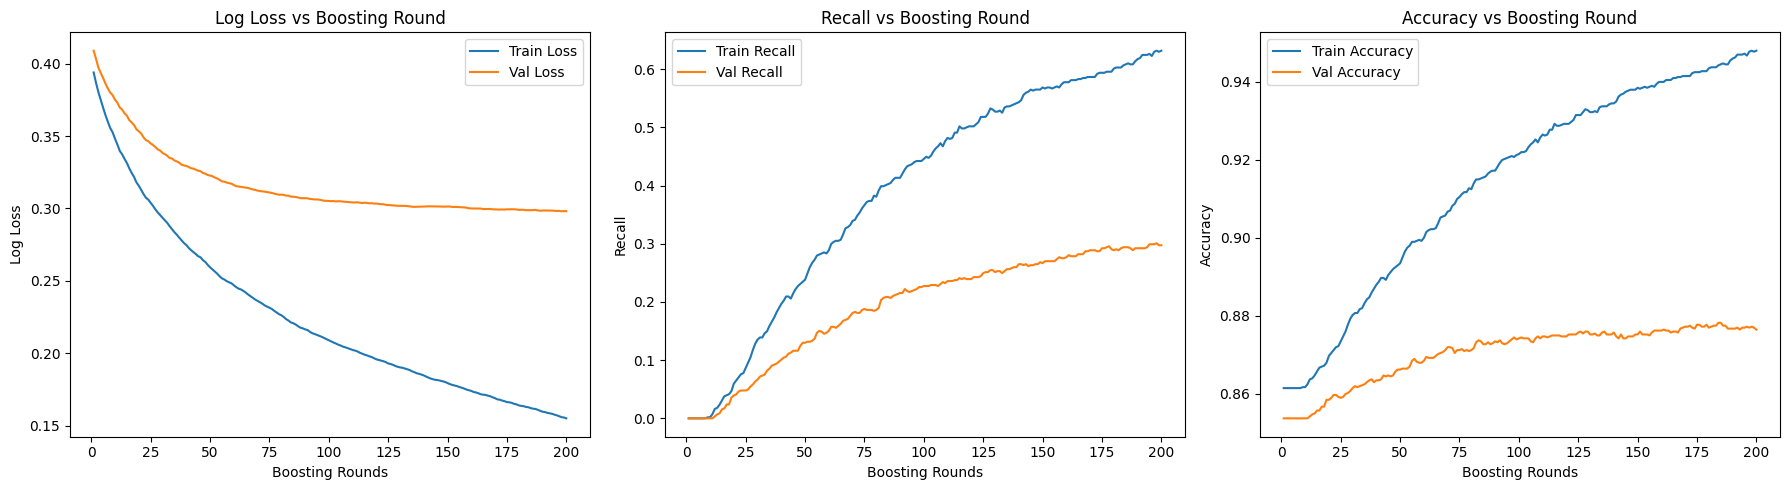

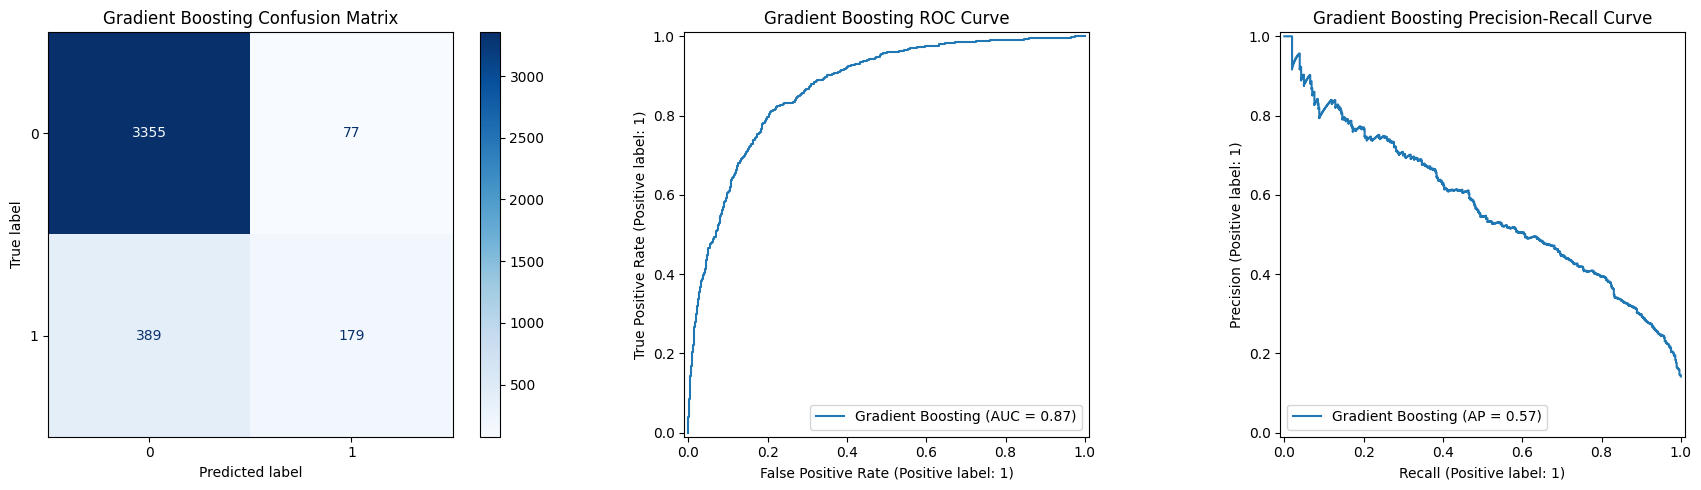

In [67]:
y_pred = (grad_boost_prob >= grad_boost_threshold).astype(int)
plot_metric_summary(y_test, y_pred, grad_boost_prob, title=f'Gradient Boosting (threshold = {grad_boost_threshold})')

epochs = np.arange(1, len(train_loss) + 1)
grad_boost_metric_fig, grad_boost_metric_axes = plt.subplots(1, 3, figsize=(18, 5))

grad_boost_metric_axes[0].plot(epochs, train_loss, label='Train Loss')
grad_boost_metric_axes[0].plot(epochs, val_loss, label='Val Loss')
grad_boost_metric_axes[0].set_title('Log Loss vs Boosting Round')
grad_boost_metric_axes[0].set_xlabel('Boosting Rounds')
grad_boost_metric_axes[0].set_ylabel('Log Loss')
grad_boost_metric_axes[0].legend()

grad_boost_metric_axes[1].plot(epochs, train_recall, label='Train Recall')
grad_boost_metric_axes[1].plot(epochs, val_recall, label='Val Recall')
grad_boost_metric_axes[1].set_title('Recall vs Boosting Round')
grad_boost_metric_axes[1].set_xlabel('Boosting Rounds')
grad_boost_metric_axes[1].set_ylabel('Recall')
grad_boost_metric_axes[1].legend()

grad_boost_metric_axes[2].plot(epochs, train_accuracy, label='Train Accuracy')
grad_boost_metric_axes[2].plot(epochs, val_accuracy, label='Val Accuracy')
grad_boost_metric_axes[2].set_title('Accuracy vs Boosting Round')
grad_boost_metric_axes[2].set_xlabel('Boosting Rounds')
grad_boost_metric_axes[2].set_ylabel('Accuracy')
grad_boost_metric_axes[2].legend()

plt.tight_layout()
plt.show()

# Populate the 3-panel Gradient Boosting evaluation figure.
grad_boost_fig, grad_boost_axes = plot_evaluation_panels(
    y_test, y_pred, grad_boost_prob, model_name='Gradient Boosting'
)

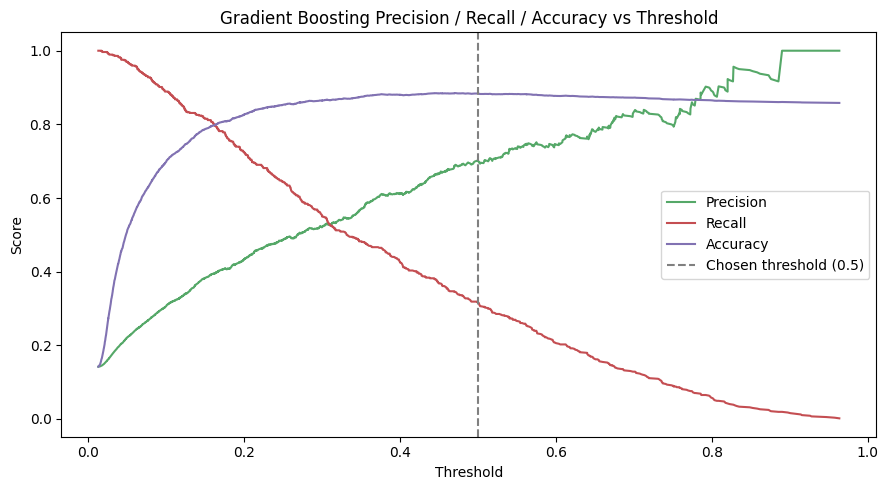

In [68]:
plot_threshold_tradeoff(
    y_test,
    grad_boost_prob,
    chosen_threshold=grad_boost_threshold,
    title='Gradient Boosting Precision / Recall / Accuracy vs Threshold'
)

In [69]:
export_predictions(df_y_test.index.values, y_pred, grad_boost_prob, model_name='GradientBoosting')

Saved predictions to ../models/GradientBoosting_results.csv


'../models/GradientBoosting_results.csv'

In [70]:
# Used to save model and standard scaler for later use in the UI.
# import joblib
# joblib.dump(ann_model, "../models/ann_model.joblib")
# joblib.dump(grad_boost_model, "../models/grad_boost_model.joblib")
# joblib.dump(scaler, "../models/scaler.joblib")

## Models Comparison


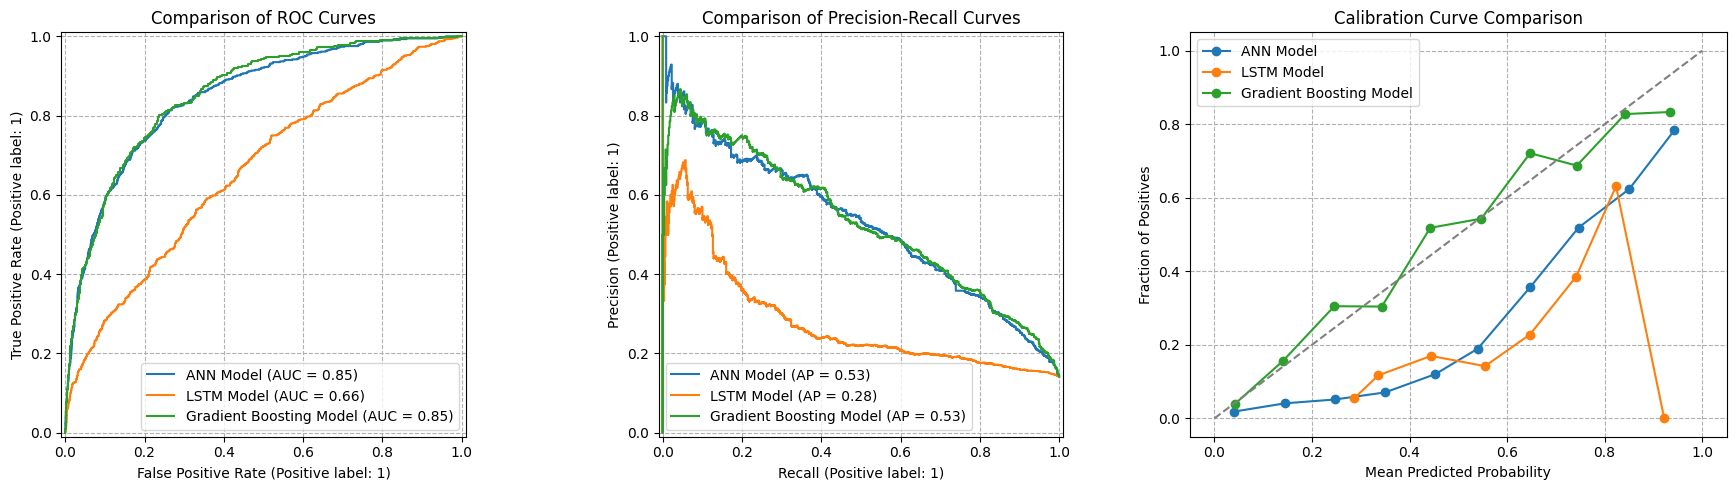

Brier Scores
ANN: 0.1407732218503952
LSTM: 0.19118215143680573
Gradient Boosting: 0.08974061894305815


In [71]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

ann_prob = ann_model.predict(x_test_scaled, verbose=0).ravel()
lstm_prob = lstm_model.predict(x_test_lstm, verbose=0).ravel()
grad_boost_prob = gradient_boosting_model.predict_proba(x_test_scaled)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve: How well does the model separate classes.
RocCurveDisplay.from_predictions(y_test, ann_prob, ax=axes[0], name='ANN Model')
RocCurveDisplay.from_predictions(y_test, lstm_prob, ax=axes[0], name='LSTM Model')
RocCurveDisplay.from_predictions(y_test, grad_boost_prob, ax=axes[0], name='Gradient Boosting Model')
axes[0].set_title('Comparison of ROC Curves')
axes[0].grid(linestyle='--')

# Precision Recall curve: How do precision and recall trade off.
PrecisionRecallDisplay.from_predictions(y_test, ann_prob, ax=axes[1], name='ANN Model')
PrecisionRecallDisplay.from_predictions(y_test, lstm_prob, ax=axes[1], name='LSTM Model')
PrecisionRecallDisplay.from_predictions(y_test, grad_boost_prob, ax=axes[1], name='Gradient Boosting Model')
axes[1].set_title('Comparison of Precision-Recall Curves')
axes[1].grid(linestyle='--')

# Calibration curve: How well do predicted proabilities reflect true probabilities.
for prob, label in [
    (ann_prob, 'ANN Model'),
    (lstm_prob, 'LSTM Model'),
    (grad_boost_prob, 'Gradient Boosting Model')
]:
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10, strategy='uniform')
    axes[2].plot(mean_pred, frac_pos, marker='o', label=label)

axes[2].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[2].set_title('Calibration Curve Comparison')
axes[2].set_xlabel('Mean Predicted Probability')
axes[2].set_ylabel('Fraction of Positives')
axes[2].legend()
axes[2].grid(linestyle='--')

plt.tight_layout()
plt.show()

print("Brier Scores")
print("ANN:", brier_score_loss(y_test, ann_prob))
print("LSTM:", brier_score_loss(y_test, lstm_prob))
print("Gradient Boosting:", brier_score_loss(y_test, grad_boost_prob))

## Findings
### ANN
- Better ranking with an AUC of about 0.79 and Average Precision of 0.67.
- Better brier score of 0.1895.
- Calibrartion curve is not perfectly diagonal (surprise), but it deviation is decent.
- Likely better due to a being a more complex model that focuses on recall and preventing overfitting.

### Gradient Boosting
TODO

In [ ]:
# Run predictions using C script for s1 and s2 scores.
# Only print se1 and se2 scores, garbage noise gets thrown to stderr
import os

try:
    for model_name in ['ANN', 'LSTM', 'GradientBoosting']:
        csv_path = f"../models/{model_name}_results.csv"
        print(f"Running score.o for {model_name} predictions:")
        cmd = (
            f"./../../score.o {csv_path} ../../data/outcomes/outcomes-b.txt "
            "2>/dev/null | grep -E '^(Se =|Unofficial Event 1 score:|Unofficial Event 2 score:)'"
        )
        os.system(cmd)
        print()
except Exception as e:
    print("Error running score.o: Do you have GCC installed?", e)

Running score.o for ANN predictions:
Se = 0.602113, PPV = 0.483734
Unofficial Event 1 score: 0.483734
Unofficial Event 2 score: 20.7317

Running score.o for LSTM predictions:
Se = 0.505282, PPV = 0.22043
Unofficial Event 1 score: 0.22043
Unofficial Event 2 score: 3132.42

Running score.o for GradientBoosting predictions:
Se = 0.315141, PPV = 0.699219
Unofficial Event 1 score: 0.315141
Unofficial Event 2 score: 54.1082



## Comparison with Physionet 2012 Challenges
- [**Winner** Patient Specific Predictions in the Intensive Care Unit
Using a Bayesian Ensemble](https://www.cinc.org/archives/2012/pdf/0249.pdf)
- [**Contestant ANN** 2012 PhysioNet Challenge: An Artificial Neural Network to Predict Mortality in
ICU Patients and Application of Solar Physics Analysis Methods](https://www.cinc.org/archives/2012/pdf/0485.pdf)

|                              | Winner | Contestant | Our ANN | Our LSTM| Our Gradient Boosting|
|------------------------------|--------|------------|---------|---------|----------------------|
| se1 (min(precision, recall)) ↑ | 0.5310 | 0.27       | 0.4837  |0.2204   | 0.3151 |
| se2 (Hosmer-Lemeshow) ↓      | 26.44  | 22.83      | 20.73   | 3132.42 | 54.10 |